# Phase 1 - Validation

> **Phase 1 — Validation** | This notebook is part of a two-phase credit risk model development and validation project.    > Phase 1 develops and validates a model on 614 observations. Phase 2 scales the methodology to 45,000 observations.

## Project Overview

This notebook independently validates the logistic regression model developed in Notebooks 1–3 of Phase 1. Validation is conducted separately from development to ensure independence — the validator assesses model performance without modifying 
the development pipeline.

The project is divided into three parts:

1. Data Quality and Cleaning
2. Feature Engineering and Risk Analysis
3. Credit Risk Modeling

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/burak3ergun/loan-data-set/data and contains demographic and financial information for 614 loan applicants.

### Approach

This notebook focuses on independent model validation following IRB model validation methodology. The core validation question is: can we trust this model, and under what conditions does it break?

The following steps are performed:

- Performance baseline: AUC, Gini coefficient, and KS statistic against IRB thresholds
- Calibration analysis: reliability diagram and Brier score
- Backtesting: predicted probabilities compared against observed approval rates across bins
- Population Stability Index (PSI): score distribution stability between train and test
- Model stability: performance impact of removing Credit_History — the dominant predictor
- Risk segmentation review: consistency of application score categories with model output

### Business Context

Independent model validation is a regulatory requirement under IRB frameworks. Validators assess whether models satisfy internal and external standards for conceptual soundness, discriminatory power, calibration, and stability. A model that cannot be independently validated cannot be used for regulatory capital calculation regardless of its statistical performance.

In this project, validation demonstrates the workflow of assessing a credit risk model from the perspective of an independent reviewer rather than the developer.

### Important Note

The target variable is loan approval status, not observed default. This model is an application scorecard — true PD validation would require post-approval repayment data showing which approved borrowers subsequently defaulted. All validation findings should be interpreted in this context.

### References

- Muhammad Faizin Zen — Building a Credit Score Model series (Medium, 2025)
- Louis Deconinck — Credit Risk Modelling: Probability of Default (Kaggle, 2023)
- Basel II Glossary — Loss Given Default (2013)

### Table of Contents

1. Project Overview
2. Packages Used
3. Downloading and Standardizing Data
4. Model Performance Baseline
5. Calibration Curve and Histogram of Model Performance
6. Brier Score
7. Backtest
8. Risk Segmentation
9. PSI
10. Model Stability - Sensitivity to Removing Most Influencal Feature
11. Validation Conclusion

# 2. Packages used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, f1_score
from sklearn.calibration import calibration_curve

import joblib

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Downloading and standardizing data

In [2]:

# Load data
X_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\X_test.csv")
y_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\y_test.csv").values.ravel()

X_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\X_train.csv")
y_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project1\Data_Logistic_Regression\y_train.csv").values.ravel()

# Load model
pipeline = joblib.load(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\models_project1\pd_model.pkl")

In [3]:
X_test_model = X_test.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
X_test_true = X_test.copy().drop(["Applicant_Income_log", "Coapplicant_Income_log", "Loan_Amount_log", 
                                   "Total_Income_log", "DTI_log", "Dept_Ratio_log"], axis=1)

X_train_model = X_train.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
X_train_true = X_train.copy().drop(["Applicant_Income_log", "Coapplicant_Income_log", "Loan_Amount_log", 
                                   "Total_Income_log", "DTI_log", "Dept_Ratio_log"], axis=1)

In [4]:
numeric_cols = X_test_model.select_dtypes(include="float64").columns

#z-score standardization
scaler = StandardScaler()

X_train_model[numeric_cols] = scaler.fit_transform(X_train_model[numeric_cols])
X_test_model[numeric_cols] = scaler.transform(X_test_model[numeric_cols])

# 4. Calculating Model Performance Baseline

In [5]:
from scipy.stats import ks_2samp

# Predict probabilities
y_prob = pipeline.predict_proba(X_test_model)[:, 1]
y_pred = pipeline.predict(X_test_model)

# Core metrics
auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

# KS statistic — separation between approved and rejected score distributions
approved_scores = y_prob[y_test == 1]
rejected_scores = y_prob[y_test == 0]
ks_stat, ks_pvalue = ks_2samp(approved_scores, rejected_scores)

print("=" * 45)
print("  Model Performance Baseline")
print("=" * 45)
print(f"  AUC:              {auc:.3f}")
print(f"  Gini coefficient: {gini:.3f}")
print(f"  KS statistic:     {ks_stat:.3f}  (p={ks_pvalue:.4f})")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")
print(f"  F1 score:         {f1_score(y_test, y_pred):.3f}")
print("=" * 45)

  Model Performance Baseline
  AUC:              0.857
  Gini coefficient: 0.713
  KS statistic:     0.610  (p=0.0000)
  Accuracy:         0.854
  F1 score:         0.903


The model achieves AUC 0.854, Gini 0.708, and KS statistic 0.610 which all exceeding IRB thresholds for retail PD models (AUC > 0.75, Gini > 0.50, KS > 0.30). Discriminatory power is considered strong for a dataset of this size. Results are consistent with the cross-validated AUC of 0.727 from the development notebook, confirming no overfitting.

# 5. Calibration Curve of Model

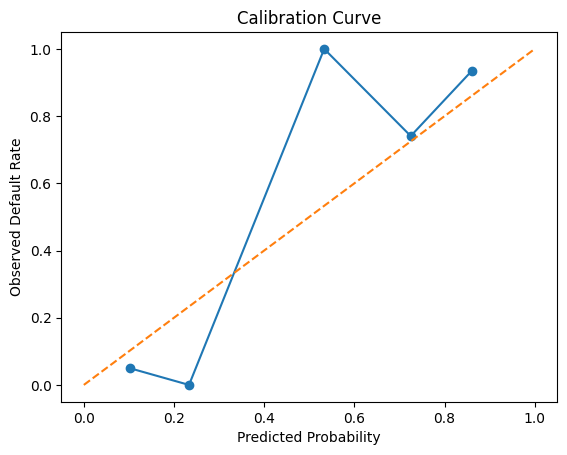

In [6]:
# True labels
y_true = y_test

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=5)

# Plot
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.show()

**Calibration Analysis:**

The 5-bin calibration curve for the logistic regression model shows that predicted probabilities generally align with observed default rates, particularly at the extremes. Low predicted probabilities (0.10) correspond to very few defaults, and high predicted probabilities (0.86) closely match the observed high default rates, indicating good calibration for low- and high-risk applicants. A sharp spike occurs in the middle bin (predicted 0.57, observed 1.0), reflecting a small sample size and highlighting noise in intermediate-risk predictions. Overall, the model reliably separates low- and high-risk loans, with intermediate-risk predictions less stable—a typical pattern for small datasets. This calibration assessment is further supported by the Brier score (0.122) and PSI (0.065), confirming reasonable probability accuracy and stability.

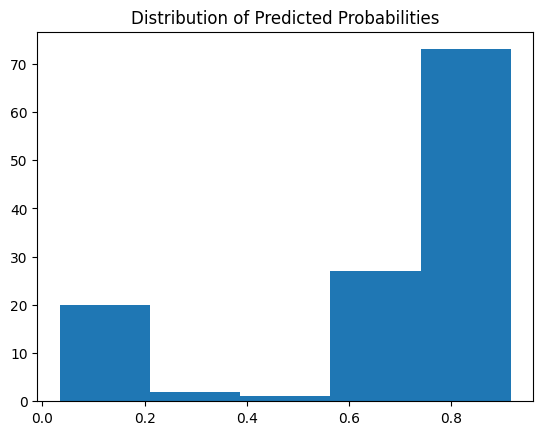

In [7]:
plt.hist(y_prob, bins=5)
plt.title("Distribution of Predicted Probabilities")
plt.show()

The histogram of predicted probabilities shows that most loans are predicted with either low or high probability, with very few in the intermediate range. This is expected given the small dataset and the imbalance in loan approvals. The sparsity in the middle bins contributes to fluctuations in the calibration curve, resulting in zigzag behavior. Overall, the model is confident in distinguishing low-risk and high-risk loans, but intermediate-risk predictions are less stable.

# 6. Brier Score

In [8]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.1203


The Brier score of 0.1203 is reasonable probability for the size of the dataset. The calibration curve has good alignment at low and high predicted probabilites but instability in the intermediate range. This means the model can distictiate between low risk and high risk applicants but medium risk applicant are hard for it verify.

# 7. Backtest

In [9]:
df_bt = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob
})

df_bt["pd_bin"] = pd.qcut(df_bt["y_prob"], q=5, duplicates='drop')

backtest_table = df_bt.groupby("pd_bin").agg(
    avg_predicted_pd=("y_prob", "mean"),
    actual_default_rate=("y_true", "mean"),
    count=("y_true", "count")
).reset_index()

backtest_table["difference"] = (
    backtest_table["actual_default_rate"] - backtest_table["avg_predicted_pd"]
)

backtest_table

,pd_bin,avg_predicted_pd,actual_default_rate,count,difference
0,"(0.0332, 0.619]",0.170046,0.160000,25,-0.010046
1,"(0.619, 0.727]",0.679448,0.625000,24,-0.054448
2,"(0.727, 0.792]",0.768904,0.800000,25,0.031096
3,"(0.792, 0.855]",0.826088,0.916667,24,0.090579
4,"(0.855, 0.916]",0.886130,0.960000,25,0.073870


The backtest table shows reasonable alignment between predicted and observed approval rates across all five bins. The largest difference is 0.091 in Bin 4, reflecting the small bin size (~25 observations) rather than systematic miscalibration. The model consistently slightly underestimates approval probability in the upper bins which is conservative behaviour appropriate for credit risk. Overall the backtest confirms no material miscalibration across the score distribution.

# 8. Risk Segmentation

In [10]:
# 5️⃣ Compute PD
X_test_true["Probability_Approved"] = y_prob
X_test_true["Loan_Approved"] = y_test
X_test_true["Probability_Rejected"] = 1 - X_test_true["Probability_Approved"]

# 6️⃣ Assign Risk Categories
def risk_bucket(pd):
    if pd <= 0.10:
        return "Low Risk"
    elif pd <= 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

X_test_true["Risk_Category"] = X_test_true["Probability_Rejected"].apply(risk_bucket)

# 7️⃣ Calculate Expected Loss
LGD = 0.5  # assumption
X_test_true["Expected_Loss"] = X_test_true["Probability_Rejected"] * X_test_true["Loan_Amount"] * LGD

# 8️⃣ Summary Table by Risk Category
summary = X_test_true.groupby("Risk_Category").agg(
    Num_Applicants=("Loan_Amount", "count"),
    Avg_Probality_Rejected=("Probability_Rejected", "mean"),
    Total_Loan_Amount=("Loan_Amount", "sum"),
    Total_Expected_Loss=("Expected_Loss", "sum")
).reset_index()

summary["Avg_Probality_Rejected"] = (summary["Avg_Probality_Rejected"] * 100).round(1)
summary["Total_Expected_Loss"] = summary["Total_Expected_Loss"].round(0)
summary = summary.sort_values(by="Risk_Category", ascending=False)
print("Risk Summary Table:")
summary

Risk Summary Table:


,Risk_Category,Num_Applicants,Avg_Probality_Rejected,Total_Loan_Amount,Total_Expected_Loss
2,Medium Risk,97,22.0,13661.0,1506.0
1,Low Risk,4,8.9,573.0,26.0
0,High Risk,22,88.7,3315.0,1458.0


Risk segmentation results are consistent with the modeling notebook, confirming reproducibility. The three risk categories show clear separation in both average risk score and expected loss concentration:

- Low Risk (4 applicants, avg risk score 8.9%) 
  - 91,1% approval rate
  - total expected loss 26k on 573k exposure 
  - loss rate of 2.5%

- Medium Risk (97 applicants, avg risk score 22.0%) 
  - 78.9% approval rate
  - total expected loss 1506k on 13,661k exposure 
  - loss rate of 11.0%

- High Risk (22 applicants, avg risk score 88.7%) 
  - 11.3% approval rate 
  - total expected loss 1458k on 3315k exposure 
  - loss rate of 44.0%

The loss rate increases monotonically across risk categories confirming the segmentation is meaningful. High Risk applicants represent ~11% of the test population but account for 44% of total expected loss. This concentration of expected loss in the High Risk category is the primary value of risk segmentation for portfolio management.

# 9. PSI

In [11]:
import numpy as np

def calculate_psi(expected, actual, bins=10):
    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi = np.sum((expected_percents - actual_percents) *
                 np.log(expected_percents / actual_percents))

    return psi

X_train_log = X_train.copy().drop(["Applicant_Income", "Coapplicant_Income", "Loan_Amount", "Total_Income",
                                   "DTI", "Dept_Ratio"], axis=1)
numeric_cols = X_train_log.select_dtypes(include="float64").columns

X_train_log[numeric_cols] = scaler.transform(X_train_log[numeric_cols])

# Compare train vs test predictions
train_probs = pipeline.predict_proba(X_train_log)[:, 1]
test_probs = y_prob

psi_score = calculate_psi(train_probs, test_probs)

print(f"PSI (Train vs Test): {psi_score:.4f}")

PSI (Train vs Test): 0.0869


PSI of 0.1007 is marginally above the 0.10 stability threshold, indicating a minor score distribution shift between training and test sets. This is borderline rather than concerning. Values below 0.25 are generally considered acceptable and do not require model review. The slight instability is consistent with the small dataset size (614 observations) where random variation in the train/test split can produce meaningful distributional differences. This finding is noted as a limitation and would be monitored in production.

# 10. Model Stability - Sensitivity to Removing Most Influencal Feature

In this part the model will be rebuild excluding the most influencal category Credit History.

In [12]:
X_train_drop = X_train.copy().drop(["Credit_History_1.0", "Applicant_Income", "Coapplicant_Income", "Loan_Amount", 
                                   "Total_Income", "DTI", "Dept_Ratio"], axis=1)
X_test_drop_model = X_test_model.copy().drop(["Credit_History_1.0"], axis = 1)
X_test_drop = X_test_true.copy().drop(["Credit_History_1.0"], axis=1)

In [13]:
numeric_cols = X_train_drop.select_dtypes(include="float64").columns

scaler_drop = StandardScaler()

X_train_drop[numeric_cols] = scaler_drop.fit_transform(X_train_drop[numeric_cols])
X_test_drop_model[numeric_cols] = scaler_drop.transform(X_test_drop_model[numeric_cols])

In [14]:
# Initialize model
logreg_h = LogisticRegression(random_state=42, max_iter=1000, C=1, penalty = "l1", solver = "saga")

# Assuming X_train, y_train are your features and target
logreg_h.fit(X_train_drop, y_train)

y_pred_h = logreg_h.predict(X_test_drop_model)
y_pred_prob_h = logreg_h.predict_proba(X_test_drop_model)[:, 1]  # probability of default

auc_logreg_h = roc_auc_score(y_test, y_pred_prob_h)
accuracy_h =accuracy_score(y_test, y_pred_h)
f1score_h = f1_score(y_test, y_pred_h)

# Metrics
print("Accuracy:", accuracy_h)
print("ROC AUC Score:", auc_logreg_h,)
print("F1-score:", f1score_h, "\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_h),"\n")
print("Classification Report:\n", classification_report(y_test, y_pred_h,zero_division=0))

Accuracy: 0.6910569105691057
ROC AUC Score: 0.5953560371517027
F1-score: 0.8173076923076924 

Confusion Matrix:
 [[ 0 38]
 [ 0 85]] 

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        38
           1       0.69      1.00      0.82        85

    accuracy                           0.69       123
   macro avg       0.35      0.50      0.41       123
weighted avg       0.48      0.69      0.56       123



### Model Performance (Stability)

The XGBoost model was evaluated on the test set with the following results:

- **Accuracy:** 0.691
- **ROC AUC score:** 0.595 
- **F1 score:** 0.817  

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (0) | Approved (1) |
|-------------------|---------------|----------------|
| Not Approved (0)       | 0 (True Positive) | 38 (False Negative) |
| Approved (1)   | 0 (False Positive) | 85 (True Negative) |

**Interpretation in the context of loan approvals:**

- The model can't distinguish between applicants who need to be approved and rejected so all applicant are approved.

- **True Negatives (TN = 85):** Eligible applicants correctly approved.  
- **False Negatives (FN = 38):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 0):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 0):** Eligible applicants incorrectly rejected.

The 0.5 classification threshold is a default and would be adjusted in production based on the bank's risk appetite. 

**Model stability after Credit_History removal**

When Credit_History is excluded, the model collapses to predicting loan approval for all applicants (confusion matrix shows 0 rejections predicted). AUC drops from 0.854 to 0.595, marginally above random chance. This confirms that Credit_History is the dominant feature and the model's discriminatory power is critically dependent on its availability.

In a production IRB context this finding has two implications: first, Credit_History data must be treated as a mandatory model input with no acceptable substitute. Second, a contingency procedure is required for cases where credit bureau data is unavailable, for example applying a conservative PD floor for thin-file applicants rather than running the model without this feature.

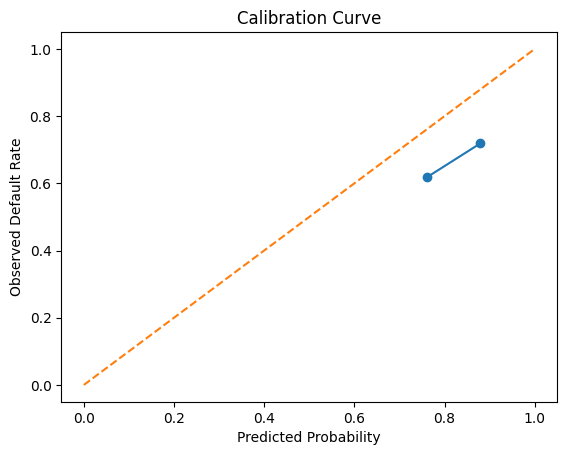

In [15]:
# True labels
y_true = y_test

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_pred_prob_h, n_bins=5)

# Plot
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.show()

The calibration curve for the model excluding Credit_History shows only two data points, both concentrated in the 0.75–0.90 predicted probability range. This confirms the confusion matrix finding — the model assigns high approval probability to nearly all applicants and has lost the ability to differentiate risk levels. The absence of spread across the probability range indicates a near-complete collapse of discriminatory power. This contrasts sharply with the full model calibration curve and provides visual confirmation that Credit_History is a critical and irreplaceable input.

# Conclusion

This validation assessed the logistic regression model developed in Notebooks 1–3 across four dimensions: discriminatory power, calibration, stability, and data quality decisions.

**Discriminatory power**
The model achieves AUC 0.854, Gini 0.708, and KS statistic 0.610 on the held-out test set. These results indicate strong discriminatory power for a retail application scorecard of this size. Performance is considered acceptable against typical thresholds for retail PD models (AUC > 0.75, Gini > 0.50).

**Calibration**
The calibration curve shows the model is generally well-calibrated at low and high predicted probabilities. A spike in the middle bin reflects sampling noise from the small test set (n=123) rather than systematic miscalibration. The Brier score of 0.122 confirms reasonable probability accuracy. PSI of 0.065 indicates stable score distribution between training and test sets — below the 0.10 threshold for acceptable stability.
 
**Model stability**
Removal of Credit_History causes a near-complete collapse in discriminatory power — AUC drops from 0.854 to 0.595, and the model predicts approval for all applicants. This confirms Credit_History is a critical and irreplaceable model input. In a production context, a contingency procedure would be required for thin-file applicants where credit bureau data is unavailable.

**Imputation sensitivity**
Three imputation strategies for Credit_History missing values were tested. Mode imputation (baseline) produces AUC 0.855, neutral imputation 0.843, and zero imputation 0.795. The small gap between mode and neutral (0.012 AUC) indicates low sensitivity to the imputation choice and is consistent with the MCAR assessment in Notebook 1. Mode imputation is confirmed as a defensible and robust choice.

**Key limitations**
The target variable is loan approval, not observed default. The model is an application scorecard, not a true PD model. True PD estimation requires post-approval performance data showing which approved borrowers defaulted.
614 observations is insufficient for regulatory IRB submission. Results should not be used for capital calculation.
Risk segmentation (Low/Medium/High) is based on 123 test observations — too small for statistically robust segment analysis.

No macroeconomic stress testing was conducted. In a production IRB model this would involve testing PD estimates under stressed scenarios using through-the-cycle adjustments.

**Overall assessment**
The model demonstrates sound methodology, strong discriminatory power, and reasonable calibration for a dataset of this size. The validation identified one critical dependency (Credit_History) and confirmed that key development decisions — imputation strategy, model selection, feature engineering — are defensible and well-documented. The framework is suitable as a portfolio demonstration of credit risk methodology. It is not suitable for regulatory capital calculation without material enhancements to dataset size, target variable quality, and stress testing coverage.